In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [2]:
n_dot = np.load("MGA-E-10032025_30ml-min_1atm_TotalSystem_MS_composition.npy")
timestamps = np.load("MGA-E-10032025_30ml-min_1atm_TotalSystem_MS_times.npy")

In [3]:
time_delta = timestamps - timestamps[0]

np.savez(
    "MGA-E-10032025_30ml-min_1atm_TotalSystem.npz", n_dot=n_dot, time_delta=time_delta
)

t_range = (time_delta.min(), time_delta.max())

In [4]:
t_offset = 7.5
t_halfperiod = 120.0

switching_times = np.full((20,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[   7.5  127.5  247.5  367.5  487.5  607.5  727.5  847.5  967.5 1087.5
 1207.5 1327.5 1447.5 1567.5 1687.5 1807.5 1927.5 2047.5 2167.5 2287.5
 2407.5]
[(7.5, 127.5), (127.5, 247.5), (247.5, 367.5), (367.5, 487.5), (487.5, 607.5), (607.5, 727.5), (727.5, 847.5), (847.5, 967.5), (967.5, 1087.5), (1087.5, 1207.5), (1207.5, 1327.5), (1327.5, 1447.5), (1447.5, 1567.5), (1567.5, 1687.5), (1687.5, 1807.5), (1807.5, 1927.5), (1927.5, 2047.5), (2047.5, 2167.5), (2167.5, 2287.5), (2287.5, 2407.5)]


In [5]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [6]:
t = np.linspace(*t_range, 481)
n_dot_interp = interp(t)

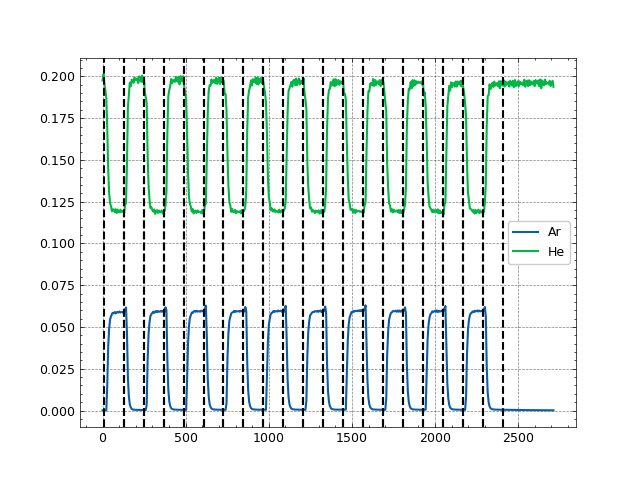

In [7]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

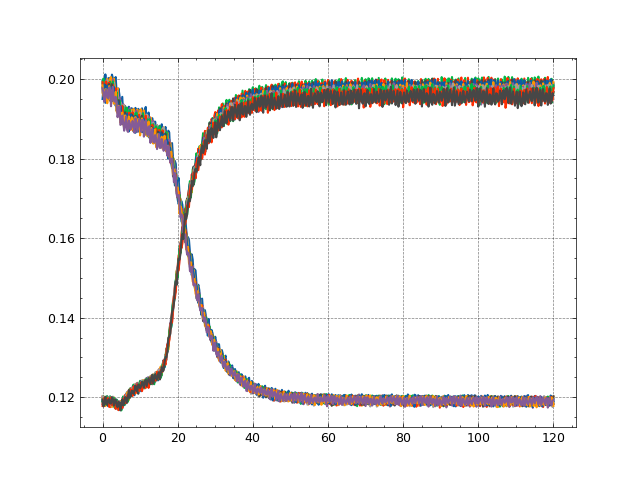

In [8]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 480 + 1)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1])

In [9]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting_5 import RTDDataModule

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_30ml-min_1atm_TotalSystem.npz"
    ),
    switching_times=switching_times,
    t_range_in=(0, 10),
    n_in=41,
    t_range_out=(0, 120),
    n_out=481,
    switch_delay=1.0,
)

In [10]:
data_total_system.setup("fit")
data_total_system.x[0]

Setup


tensor([[0.0004, 0.0004, 0.0004, 0.0004, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595]], dtype=torch.float64)

In [11]:
%matplotlib notebook
fig = plt.figure()
index = 0
plt.plot(
    data_total_system.t_in[index],
    data_total_system.x[index].squeeze(),
    ls="--",
)
plt.plot(
    data_total_system.t_in[index + 2],
    data_total_system.x[index + 2].squeeze(),
    ls="--",
)
plt.plot(
    data_total_system.t_out[index],
    data_total_system.y[index].squeeze(),
    "o",
    c="C0",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_out[index + 2],
    data_total_system.y[index + 2].squeeze(),
    "o",
    c="C1",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_in[index + 1],
    data_total_system.x[index + 1].squeeze(),
    ls="--",
    c="C2",
)
plt.plot(
    data_total_system.t_in[index + 3],
    data_total_system.x[index + 3].squeeze(),
    ls="--",
    c="C3",
)
plt.plot(
    data_total_system.t_out[index + 1],
    data_total_system.y[index + 1].squeeze(),
    "o",
    c="C2",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_out[index + 3],
    data_total_system.y[index + 3].squeeze(),
    "o",
    c="C3",
    markersize=0.5,
)
plt.show()

<IPython.core.display.Javascript object>